In [6]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

In [2]:
df = sns.load_dataset("tips")

In [3]:
df

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


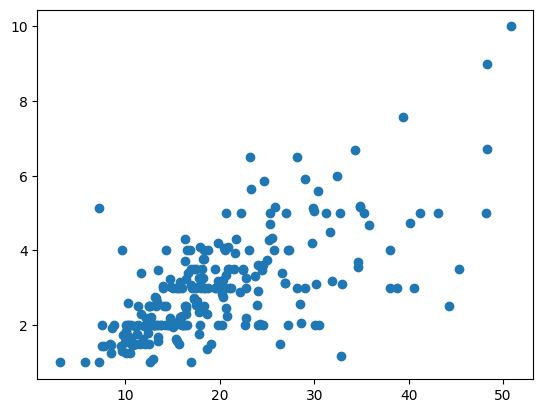

In [4]:
plt.scatter(df["total_bill"], df["tip"])

In [8]:
m = LinearRegression()
X = df[["total_bill"]]
y = df["tip"]
m.fit(X,y)
df["predict"] = m.predict(X)

In [10]:
m.coef_, m.intercept_

(array([0.10502452]), 0.920269613554674)

In [11]:
df

,total_bill,tip,sex,smoker,day,time,size,predict
0,16.99,1.01,Female,No,Sun,Dinner,2,2.704636
1,10.34,1.66,Male,No,Sun,Dinner,3,2.006223
2,21.01,3.50,Male,No,Sun,Dinner,3,3.126835
3,23.68,3.31,Male,No,Sun,Dinner,2,3.407250
4,24.59,3.61,Female,No,Sun,Dinner,4,3.502822
...,...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3,3.969131
240,27.18,2.00,Female,Yes,Sat,Dinner,2,3.774836
241,22.67,2.00,Male,Yes,Sat,Dinner,2,3.301175
242,17.82,1.75,Male,No,Sat,Dinner,2,2.791807


In [13]:
df = pd.get_dummies(df, columns=["sex", "smoker", "day", "time"])

In [34]:
df_original = df

/var/folders/66/3xy4pms51yv71qx6t0_h8ht00000gn/T/ipykernel_68088/2531487647.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["single"] = df["size"] == 1
/var/folders/66/3xy4pms51yv71qx6t0_h8ht00000gn/T/ipykernel_68088/2531487647.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["per_person"] = df["total_bill"] / df["size"]
/var/folders/66/3xy4pms51yv71qx6t0_h8ht00000gn/T/ipykernel_68088/2531487647.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Tr

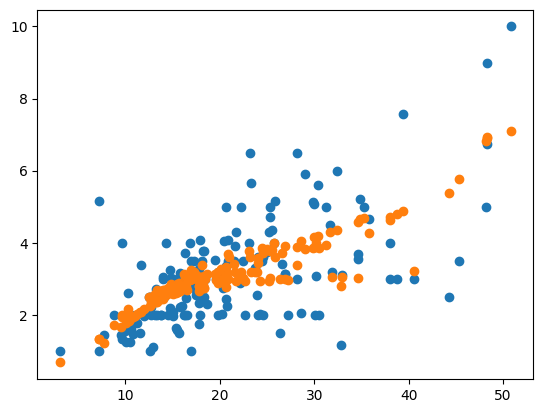

In [35]:
df = df_original[df_original["day_Sun"] | df_original["day_Sat"]]

df["single"] = df["size"] == 1
df["per_person"] = df["total_bill"] / df["size"]

df["x2"] = df["total_bill"] ** 2
df["x3"] = df["total_bill"] ** 3

if "predict" in df.columns:
    df.drop("predict", axis=1, inplace=True)

m = LinearRegression()
X = df.drop("tip", axis=1)
y = df["tip"]
m.fit(X,y)
df["predict"] = m.predict(X)

plt.scatter(df["total_bill"], df["tip"])
plt.scatter(df["total_bill"], df["predict"])

In [32]:
X

,total_bill,size,sex_Male,sex_Female,smoker_Yes,smoker_No,day_Thur,day_Fri,day_Sat,day_Sun,time_Lunch,time_Dinner,single,per_person,x2
0,16.99,2,False,True,False,True,False,False,False,True,False,True,False,8.495000,288.6601
1,10.34,3,True,False,False,True,False,False,False,True,False,True,False,3.446667,106.9156
2,21.01,3,True,False,False,True,False,False,False,True,False,True,False,7.003333,441.4201
3,23.68,2,True,False,False,True,False,False,False,True,False,True,False,11.840000,560.7424
4,24.59,4,False,True,False,True,False,False,False,True,False,True,False,6.147500,604.6681
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
239,29.03,3,True,False,False,True,False,False,True,False,False,True,False,9.676667,842.7409
240,27.18,2,False,True,True,False,False,False,True,False,False,True,False,13.590000,738.7524
241,22.67,2,True,False,True,False,False,False,True,False,False,True,False,11.335000,513.9289
242,17.82,2,True,False,False,True,False,False,True,False,False,True,False,8.910000,317.5524
